# Loss vs. Learning Rate

The learning rate is the single most consequential optimizer setting. Every other hyperparameter
changes what the model *can* represent; this one decides whether the optimizer ever finds it. Get it
wrong by an order of magnitude in either direction and a perfectly good architecture produces
garbage.

This demo trains the **same regression network** at learning rates spanning five orders of magnitude
and plots the best validation loss reached at each — revealing the classic U-shape: too small never
gets there, too large diverges.

## Learning objectives

- State the gradient-descent update rule and identify the role of the learning rate in it
- Explain the two distinct failure modes at the small and large ends of the range
- Sweep a hyperparameter on a logarithmic grid and plot the result on log axes
- Recognize that the best learning rate is problem-specific and must be re-found when anything changes

## Background

This notebook assumes the Keras `Sequential` model, `compile`, and `fit` from
`U1-3_Regression-5_KerasIntro`, including the Adam optimizer and its learning rate $\alpha$, which
is the quantity swept here. The dataset is the same noisy sine wave used there.

**Prerequisites:** `U1-3_Regression-5_KerasIntro` (building, compiling, and fitting a Keras model;
Adam and its $\alpha$)

**Dataset:** none — a noisy sine wave generated in section 1, matching
`U1-3_Regression-5_KerasIntro`.

**References:** https://keras.io/api/optimizers/adam/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. The dataset

The same noisy sine wave as `U1-3_Regression-5_KerasIntro`, so the only thing that differs between
the two notebooks is the learning rate. Holding the data and the architecture fixed is what makes
the sweep below attributable to $\alpha$ alone.

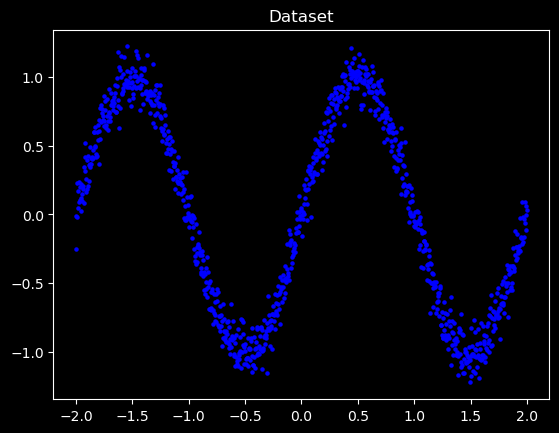

In [2]:
from sklearn.model_selection import train_test_split

nPts = 1000

x = np.linspace(-2, 2, nPts)
X = x[:, np.newaxis]

# noisy sine wave (same dataset as U1-3_Regression-5_KerasIntro)
y = np.sin(2*np.pi*x/2) + np.random.normal(0, 0.1, nPts)

plt.scatter(x, y, c='b', s=5)
plt.title('Dataset')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## 2. Sweep the learning rate

Every optimizer in this course is a variation on one update: step downhill, proportional to the
gradient.

$$\theta \leftarrow \theta - \alpha \nabla_\theta \mathcal{L}$$

The learning rate $\alpha$ is the length of that step, and both failure modes fall straight out of
this formula.

**Too small.** The step is short, so progress per update is tiny. Nothing is unstable — the
optimizer is simply still descending when the epoch budget runs out. At $\alpha = 10^{-4}$ with 80
epochs, the network never reaches the bottom, and the loss you record is wherever it happened to
stop. This failure is invisible from the loss value alone; it looks like a model that cannot fit,
when the truth is a model that was not given time.

**Too large.** Now the step overshoots the minimum and lands further up the opposite wall. For a
quadratic bowl with curvature $\lambda$ (an eigenvalue of the Hessian), gradient descent converges
only when

$$\alpha < \frac{2}{\lambda}$$

Above that threshold each step increases the loss and the iterates diverge. The loss does not
plateau high — it blows up.

So the two ends fail for genuinely different reasons: the left end is *too slow*, the right end is
*unstable*. Between them sits a broad basin where training works, and we find it by trying the whole
range. The sweep is logarithmic — `10**np.linspace(-4, 1, 11)` — because the interesting behavior
spans orders of magnitude, and a linear grid would waste nearly every point on the large end.

Both plot axes are logarithmic for the same reason.

0.0001


0.00031622776601683794


0.001


0.0031622776601683794


0.01


...

0.1


0.31622776601683794


1.0


3.1622776601683795


10.0


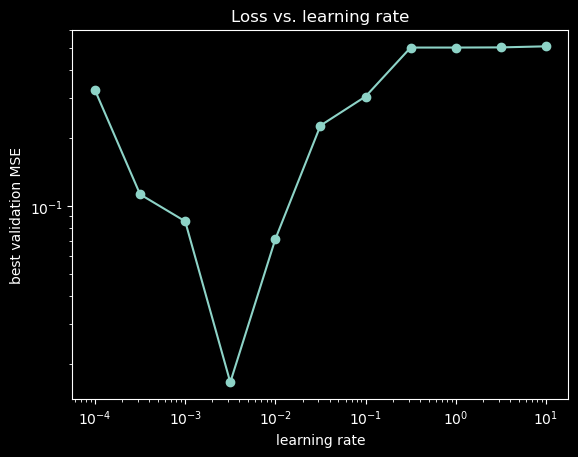

In [3]:
from keras.models import Sequential
from keras.layers import *
from keras.optimizers import Adam

#lrs = [10.0, 1.0, 0.1, 0.01, 0.001, 0.0001]
lrs = 10**np.linspace(-4, 1, 11)
val_losses = []

for lr in lrs:
    print(lr)

    model = Sequential([
        Input(shape=X.shape[1:]),
        Dense(10, activation='relu'),
        Dense(10, activation='relu'),
        Dense(1, activation='linear'),
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse'
    )

    history = model.fit(
        X_train, y_train,
        epochs=80,
        batch_size=32,
        shuffle=True,
        validation_data=(X_test, y_test),
        verbose=0
    )

    val_losses.append(
        min(history.history['val_loss'])
    )

plt.plot(lrs, val_losses, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('learning rate')
plt.ylabel('best validation MSE')
plt.title('Loss vs. learning rate');

Both ends of the curve fail for different reasons: at `1e-4` the optimizer crawls and 80 epochs
aren't nearly enough; at `10` the updates overshoot and the loss never settles. The sweet spot sits
in the middle — and it moves when the data scale, architecture, or batch size change, which is why
this sweep is worth re-running per problem (it reappears on real data in `U1_RealEstate-4_Keras`).

Note the shape of the basin: it is **wide and flat-bottomed** on a log axis, spanning something like
two orders of magnitude rather than a single sharp value. This is the practical takeaway. You do not
need the optimal learning rate, you need one in the basin — which is why a coarse log-spaced sweep
like this one is enough, and why Adam's default of `0.001` works so often without any tuning at all.

## 3. Review

- **The learning rate $\alpha$ is the step size** in $\theta \leftarrow \theta - \alpha \nabla_\theta \mathcal{L}$,
  and it decides whether the optimizer finds the minimum a given architecture is capable of.
- **The two failure modes are different in kind.** Too small is *slow* — the optimizer is still
  descending when the epochs run out. Too large is *unstable* — steps overshoot and the loss
  diverges, which for a quadratic bowl of curvature $\lambda$ happens once $\alpha \ge 2/\lambda$.
- **Sweep on a log grid and plot on log axes.** The effect spans orders of magnitude, so a linear
  grid resolves the wrong region.
- **The good region is a wide basin, not a point**, which is why coarse sweeps suffice and why
  Adam's `0.001` default is a reasonable starting guess.
- **The basin moves** with data scale, architecture, and batch size. Re-run the sweep when any of
  those change rather than reusing a learning rate that worked elsewhere.